In [ ]:
# plane="xy" → fixed z
# plane="xz" → fixed y
# plane="yz" → fixed x

# along="x" → fixed y and z
# along="y" → fixed x and z
# along="z" → fixed x and y

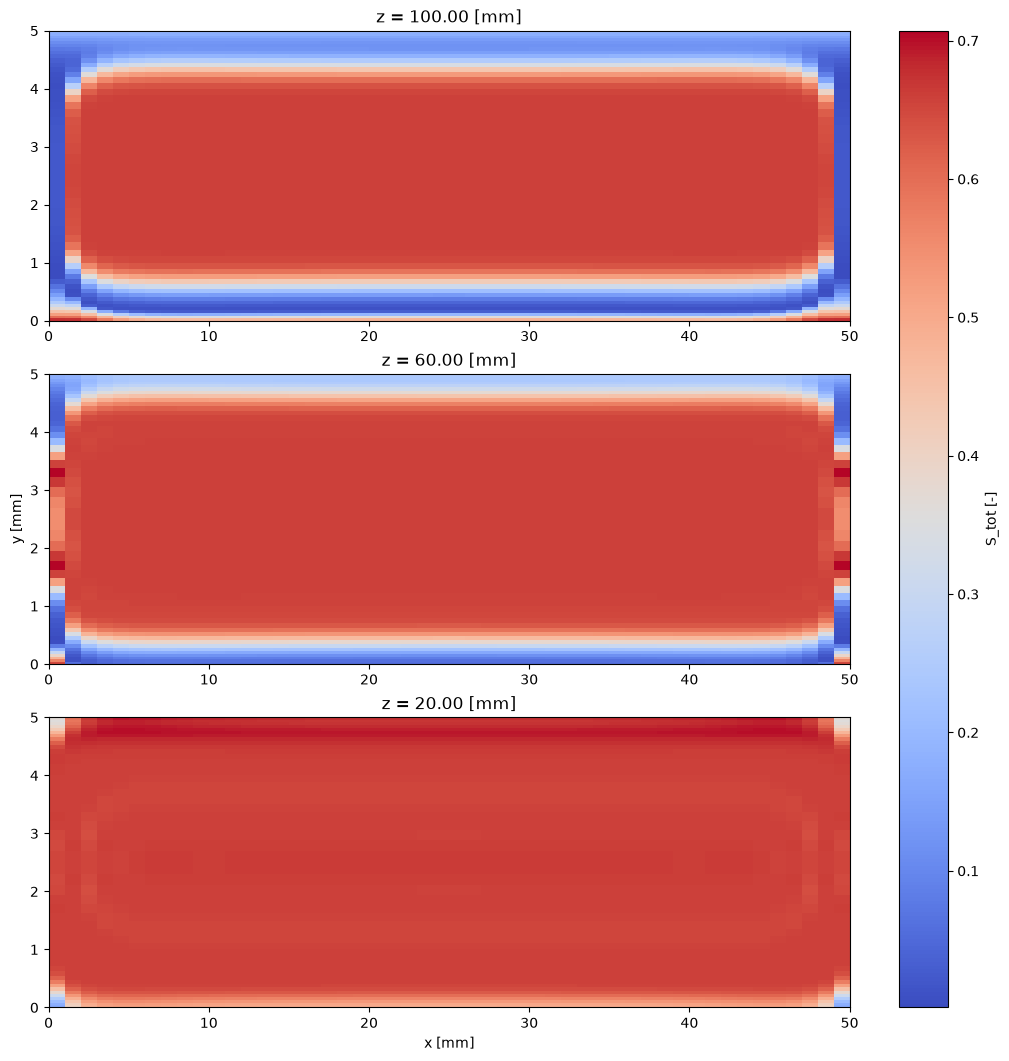

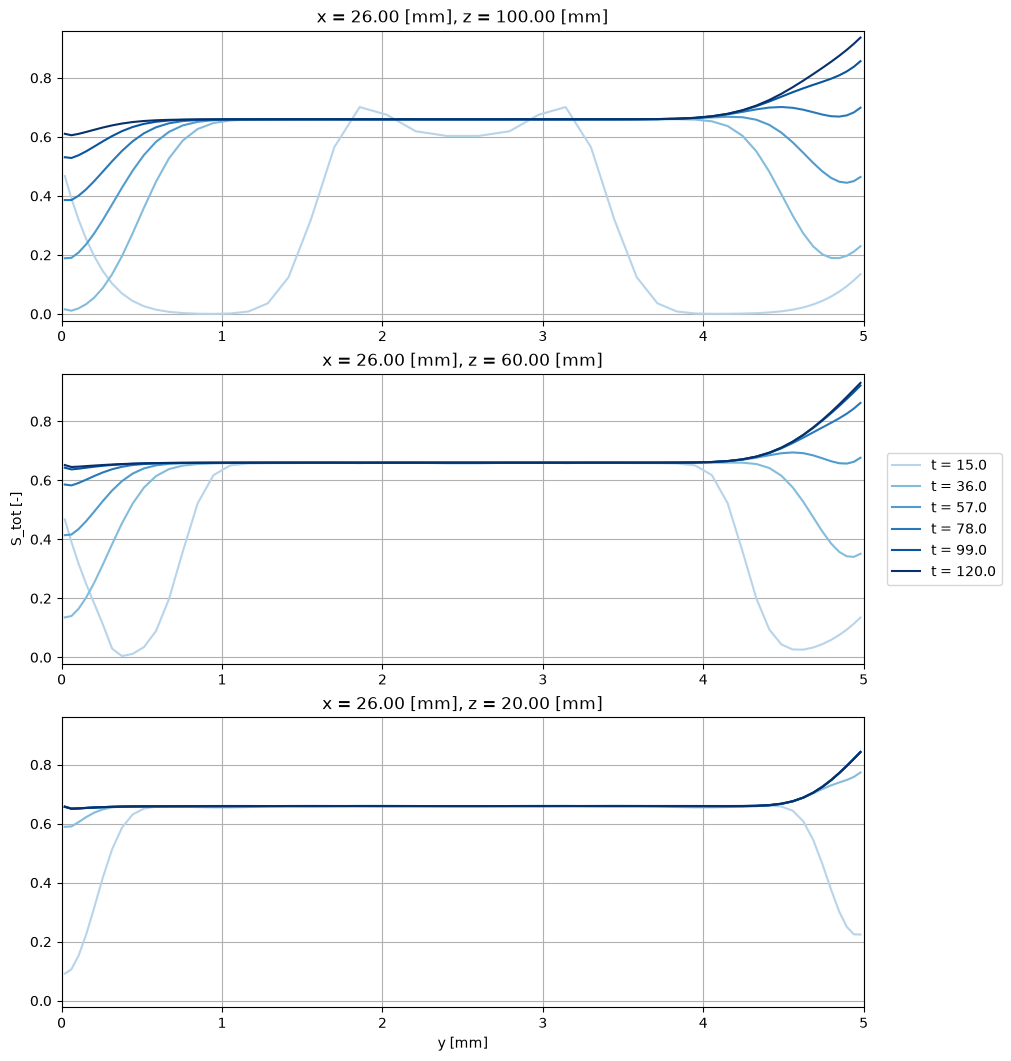

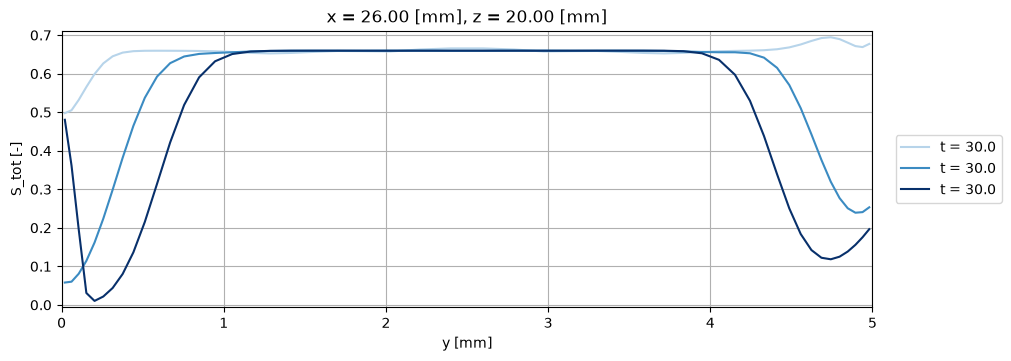

(<Figure size 1000x350 with 1 Axes>,
 [<Axes: title={'center': 'x = 26.00 [mm], z = 20.00 [mm]'}, xlabel='y [mm]', ylabel='S_tot [-]'>])

In [ ]:
import Post_new
import Plot_new

import importlib
importlib.reload(Post_new)
importlib.reload(Plot_new)

from Post_new import OpenFOAMRawCase
from Plot_new import plot_slice, plot_profiles

import numpy as np 

ofdir = '/home/au672287/OpenFOAM/au672287-v2512/run/projects/mesh_ind/50_100'
savedir = '/home/au672287/OpenFOAM/au672287-v2512/run/post/mesh_ind/data'
case = OpenFOAMRawCase(ofdir)

slice_target = [0.02, 0.06, 0.1]
line_target = 0.025
times = np.linspace(15, 120, 6)
stime = 30
field = 'S_tot'
plane = 'xy'
dim = 'y'
fix = 'xz'

S = []
for st in slice_target:
    s = case.slice(
        time=stime,
        field=field,
        plane=plane,
        value=st,
    )
    S.append(s)

P = []
for st in slice_target:
    pd = []
    for t in times:
        p = case.profile(
            time=t,
            field=field,
            along=dim,
            fixed={fix[0]: line_target, fix[1]: st},
        )
        pd.append(p)
    P.append(pd)

# plot_slice(S[0], unit=["[mm]", "[-]"], scale=1e3)
plot_slice(
    S, 
    unit=["[mm]", "[-]"], 
    scale=1e3,
    ixlabel=2,
    iylabel=1,
    nRound=3,
    flip=True,
    # savedir=savedir,
    # savename=fieldprofile
    )
# plot_profiles(P[0][0], unit=['[mm]','[-]'],scale=1e3, nRound=3)
# plot_profiles(P[0], unit=['[mm]','[-]'],scale=1e3, nRound=3, ilegend=0, xlim=[0, 5])
plot_profiles(
    P, 
    unit=['[mm]','[-]'],
    scale=1e3,
    iylabel=1,
    ixlabel=2, 
    ilegend=1, 
    nRound=3, 
    flip=True, 
    color='Blues', 
    colorgrad=[0.3, 1.0], 
    xlim=[0, 5],
    # ylim=[0, 1], 
    pad=0.025,
    # savedir=savedir,
    # savename=fieldprofile
    )

# fix this 
# if looping over z and keep time constant
# single plot should be able to be both time and space 

P = []
for st in slice_target:
    p = case.profile(
        time=stime,
        field=field,
        along=dim,
        fixed={fix[0]: line_target, fix[1]: st},
    )
    P.append(p)

plot_profiles(
    P, 
    unit=['[mm]','[-]'],
    scale=1e3,
    ilegend=0, 
    nRound=3, 
    flip=True, 
    color='Blues', 
    colorgrad=[0.3, 1.0], 
    xlim=[0, 5],
    # ylim=[0, 1], 
    pad=0.025,
    # savedir=savedir,
    # savename=fieldprofile
    )

